In [2]:
# =====================================================================
# PLANTILLA GENÉRICA: Clasificación Multiclase con Imágenes de Drive
# =====================================================================

# ---------------------------------------------------------------------
# PASO 1: Conectar a Google Drive
# ---------------------------------------------------------------------
#from google.colab import drive
#drive.mount('/content/drive')

# ---------------------------------------------------------------------
# PASO 2: Importar Librerías
# ---------------------------------------------------------------------
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision.models as models
from pathlib import Path
import cv2

In [3]:

# Selección automática de hardware
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Trabajando con el dispositivo: {device}\n")

# ---------------------------------------------------------------------
# PASO 3: Configurar Rutas y Número de Clases (¡MODIFICA AQUÍ!)
# ---------------------------------------------------------------------
# Ajusta el nombre de la carpeta raíz si es necesario
RUTA_TRAIN = '/home/pprezp/Documentos/Desarrollos/DSRN_UAEMEX/Modulo_04/CNN_Multiclase/train'
RUTA_TEST = '/home/pprezp/Documentos/Desarrollos/DSRN_UAEMEX/Modulo_04/CNN_Multiclase/test'
# ---------------------------------------------------------------------
# PASO 4: Carga de Datos y Auto-detección de Clases
# ---------------------------------------------------------------------
transformaciones = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(root=RUTA_TRAIN, transform=transformaciones)
test_dataset = ImageFolder(root=RUTA_TEST, transform=transformaciones)

# Guardamos dinámicamente cuántas clases detectó ImageFolder en Drive
NUM_CLASES = len(train_dataset.classes) 

print(f"¡Configuración Multiclase Detectada!")
print(f"Número de clases encontradas: {NUM_CLASES}")
print(f"Nombres de las clases: {train_dataset.classes}")
print(f"Mapeo de índices: {train_dataset.class_to_idx}\n")

BATCH_SIZE = 32
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Trabajando con el dispositivo: cuda

¡Configuración Multiclase Detectada!
Número de clases encontradas: 6
Nombres de las clases: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Mapeo de índices: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}



In [4]:
# ---------------------------------------------------------------------
# PASO 5: Arquitectura de la CNN Adaptable a N Clases
# ---------------------------------------------------------------------
class CNNMulticlass(nn.Module):
    def __init__(self, num_clases_salida):
        super(CNNMulticlass, self).__init__()
        
        # Extractor de características (Igual al modelo base)
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 112x112
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # 56x56
        )
        
        # Clasificador
        self.classifier = nn.Sequential(
            nn.Linear(32 * 56 * 56, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            # ¡CLAVE!: En lugar de un número fijo (2), recibe la variable dinámica de clases
            nn.Linear(128, num_clases_salida) 
        )
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

#Pasamos NUM_CLASES como argumento al constructor
model = CNNMulticlass(num_clases_salida=NUM_CLASES).to(device)

In [5]:
# ---------------------------------------------------------------------
# PASO 6: Función de Pérdida y Optimidad
# ---------------------------------------------------------------------
# Nota para la clase: CrossEntropyLoss maneja internamente Softmax, por lo que
# es perfectamente compatible tanto para biclase como para multiclase en PyTorch.
criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [6]:
# ---------------------------------------------------------------------
# PASO 7: Bucle de Entrenamiento
# ---------------------------------------------------------------------
NUM_EPOCHS = 15
print("Iniciando el entrenamiento multiclase...")

for epoch in range(NUM_EPOCHS):
    model.train()
    loss_acumulada = 0.0
    
    for imagenes, etiquetas in train_loader:
        imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)
        
        predicciones = model(imagenes)
        loss = criterion(predicciones, etiquetas)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        loss_acumulada += loss.item()
        
    print(f"Época [{epoch+1}/{NUM_EPOCHS}] - Pérdida Promedio: {loss_acumulada/len(train_loader):.4f}")

print("¡Entrenamiento concluido!\n")

Iniciando el entrenamiento multiclase...
Época [1/15] - Pérdida Promedio: 1.0606
Época [2/15] - Pérdida Promedio: 0.7317
Época [3/15] - Pérdida Promedio: 0.5397
Época [4/15] - Pérdida Promedio: 0.4004
Época [5/15] - Pérdida Promedio: 0.2791
Época [6/15] - Pérdida Promedio: 0.2194
Época [7/15] - Pérdida Promedio: 0.1707
Época [8/15] - Pérdida Promedio: 0.1394
Época [9/15] - Pérdida Promedio: 0.1126
Época [10/15] - Pérdida Promedio: 0.1022
Época [11/15] - Pérdida Promedio: 0.1096
Época [12/15] - Pérdida Promedio: 0.0884
Época [13/15] - Pérdida Promedio: 0.0826
Época [14/15] - Pérdida Promedio: 0.0734
Época [15/15] - Pérdida Promedio: 0.0718
¡Entrenamiento concluido!



In [7]:
# ---------------------------------------------------------------------
# PASO 8: Evaluación Final en el Set de Prueba (Test)
# ---------------------------------------------------------------------
model.eval()
correctos = 0
total_imagenes = 0

with torch.no_grad():
    for imagenes, etiquetas in test_loader:
        imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)
        outputs = model(imagenes)
        _, predicciones_indices = torch.max(outputs.data, 1)
        
        total_imagenes += etiquetas.size(0)
        correctos += (predicciones_indices == etiquetas).sum().item()

accuracy = 100 * correctos / total_imagenes
print(f"Exactitud (Accuracy) final en TEST para las {NUM_CLASES} clases: {accuracy:.2f}%")

Exactitud (Accuracy) final en TEST para las 6 clases: 77.63%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


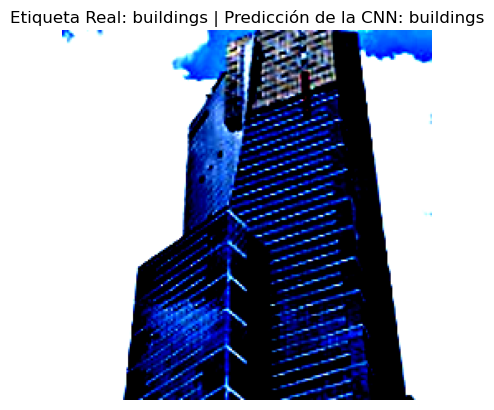

In [8]:
imagenes_muestra, etiquetas_muestra = next(iter(test_loader))
con_prediccion = model(imagenes_muestra.to(device))
_, prediccion = torch.max(con_prediccion, 1)

idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

# Dibujar el primer elemento del lote
plt.imshow(imagenes_muestra[0].squeeze().numpy().transpose(1, 2, 0))
plt.title(f"Etiqueta Real: {idx_to_class[etiquetas_muestra[0].item()]} | Predicción de la CNN: {idx_to_class[prediccion[0].item()]}")
plt.axis('off')
plt.show()

/home/pprezp/Documentos/Desarrollos/DSRN_UAEMEX/Modulo_04/CNN_Multiclase/pred/10004.jpg


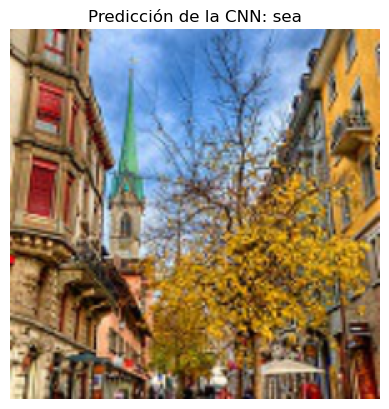

/home/pprezp/Documentos/Desarrollos/DSRN_UAEMEX/Modulo_04/CNN_Multiclase/pred/10005.jpg


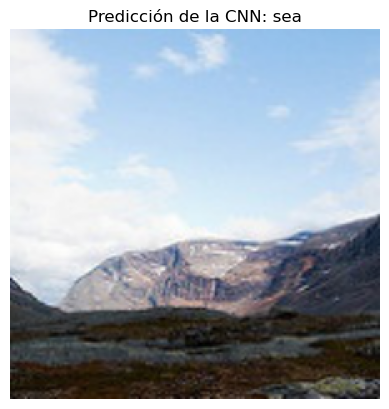

/home/pprezp/Documentos/Desarrollos/DSRN_UAEMEX/Modulo_04/CNN_Multiclase/pred/10012.jpg


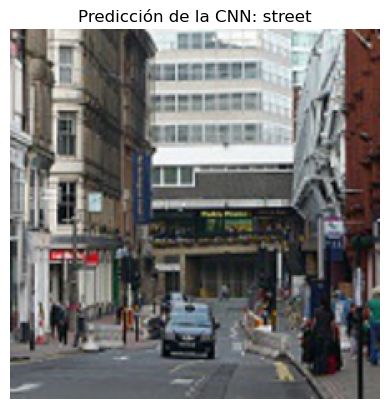

/home/pprezp/Documentos/Desarrollos/DSRN_UAEMEX/Modulo_04/CNN_Multiclase/pred/10013.jpg


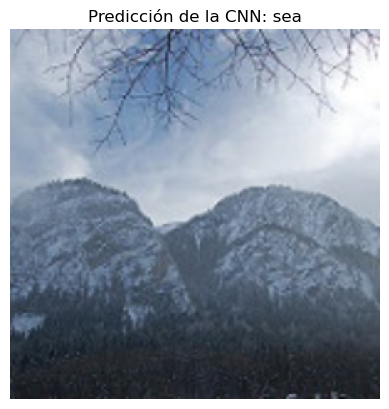

/home/pprezp/Documentos/Desarrollos/DSRN_UAEMEX/Modulo_04/CNN_Multiclase/pred/10017.jpg


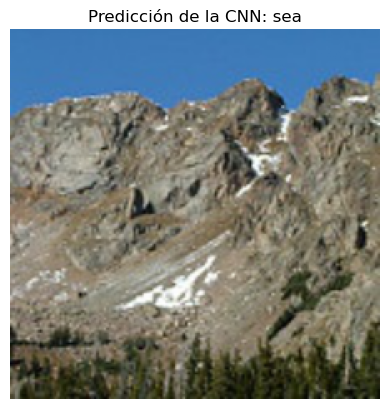

/home/pprezp/Documentos/Desarrollos/DSRN_UAEMEX/Modulo_04/CNN_Multiclase/pred/10021.jpg


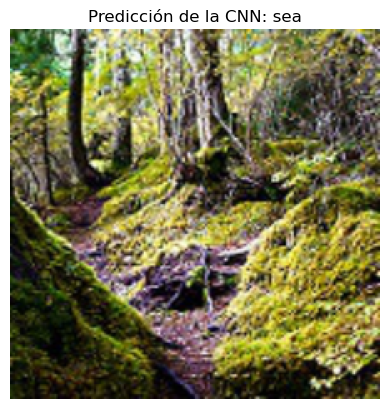

/home/pprezp/Documentos/Desarrollos/DSRN_UAEMEX/Modulo_04/CNN_Multiclase/pred/1003.jpg


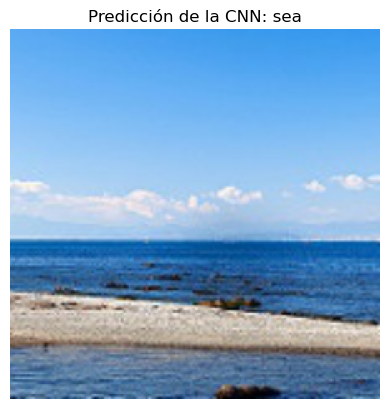

/home/pprezp/Documentos/Desarrollos/DSRN_UAEMEX/Modulo_04/CNN_Multiclase/pred/10034.jpg


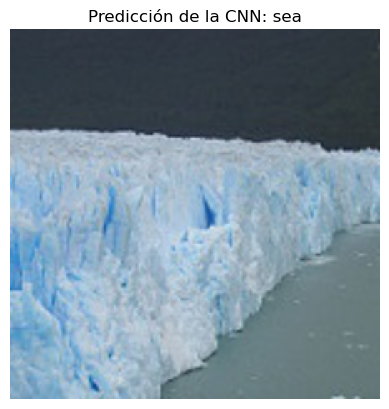

/home/pprezp/Documentos/Desarrollos/DSRN_UAEMEX/Modulo_04/CNN_Multiclase/pred/10038.jpg


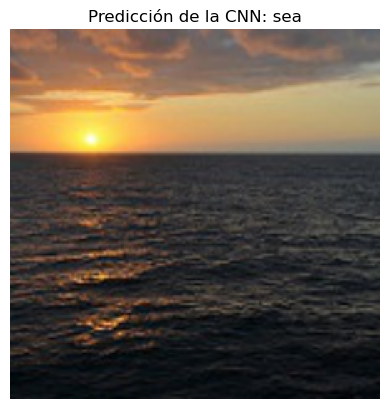

/home/pprezp/Documentos/Desarrollos/DSRN_UAEMEX/Modulo_04/CNN_Multiclase/pred/10040.jpg


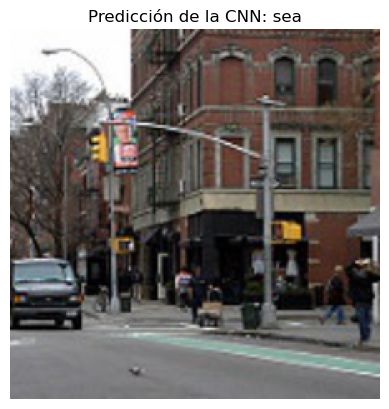

In [10]:


RUTA_PRED = '/home/pprezp/Documentos/Desarrollos/DSRN_UAEMEX/Modulo_04/CNN_Multiclase/pred/'

folder = Path(RUTA_PRED)
imagenes = [ str.lower(f.name) for f in folder.glob('*.jpg*') if f.is_file() ]


for i in range( 10 ):
    img = cv2.imread( RUTA_PRED + imagenes[i] )
    print( RUTA_PRED + imagenes[i] )
    image_resized = cv2.resize(img, (224, 224))
    img_rgb = cv2.cvtColor(image_resized, cv2.COLOR_BGR2RGB)

    tensor_kitten = torch.from_numpy(img_rgb).permute(2, 0, 1).float() / 255.0
    tensor_kitten = tensor_kitten.unsqueeze(0)

    con_prediccion = model(tensor_kitten.to(device))
    _, prediccion = torch.max(con_prediccion, 1)

    plt.imshow(tensor_kitten.squeeze().numpy().transpose(1, 2, 0))
    plt.title(f"Predicción de la CNN: {idx_to_class[prediccion[0].item()]}")
    plt.axis('off')
    plt.show()
